# Ensemble Bayesian Markov Switching Model   

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

asset = "bitcoin"

# Load dataset (Replace this with your actual CSV file)
df_1 = pd.read_csv(f"/Users/valter.rebelo/MissionControl/micro/candleData/{asset}_candles.csv")
df_1['date'] = pd.to_datetime(df_1['date'])
df_1.set_index('date', inplace=True)

df_2 = pd.read_csv(f"/Users/valter.rebelo/MissionControl/micro/assetData/{asset}.csv")
df_2['date'] = pd.to_datetime(df_2['date'])
df_2.set_index('date', inplace=True)

data = pd.merge(df_1, df_2[['total_volume']], on='date', how='inner')

#data = data[data.index > '2013-12-31']

data.rename(columns={'total_volume': 'Volume',
                     'open': 'Open',
                     'high': 'High',
                     'low': 'Low',
                     'close': 'Close'}, inplace=True)

data.index.name = 'Date'

data 

,Open,High,Low,Close,Volume
Date,,,,,
2013-04-27,NaN,NaN,NaN,NaN,0.000000e+00
2013-04-28,NaN,NaN,NaN,NaN,0.000000e+00
2013-04-29,135.30,135.30,135.30,135.30,0.000000e+00
2013-04-30,141.96,141.96,141.96,141.96,0.000000e+00
2013-05-01,135.30,135.30,135.30,135.30,0.000000e+00
...,...,...,...,...,...
2025-02-04,101392.00,101730.00,96026.00,98118.00,7.319669e+10
2025-02-05,101392.00,101730.00,96026.00,98118.00,4.884896e+10
2025-02-06,97888.00,98949.00,96212.00,96583.00,4.446218e+10


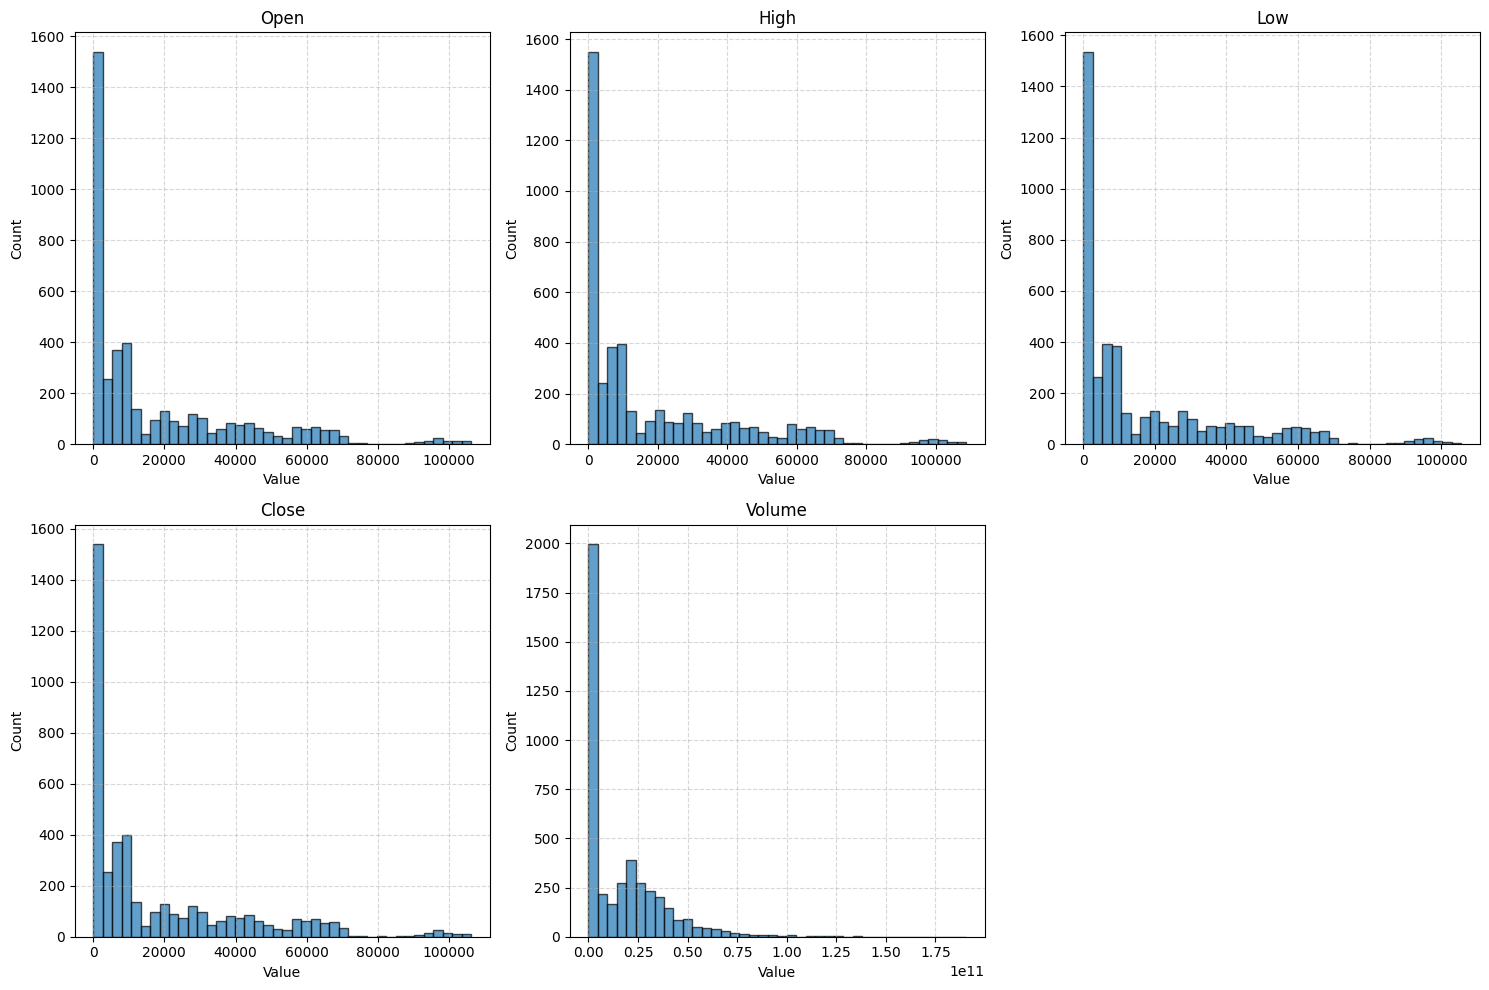

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_distributions(df, feature_cols=None, bins=50, figsize=(15, 10)):
    """
    Plots the distribution (histograms) of specified feature columns in a DataFrame.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing your features.
    feature_cols : list of str, optional
        List of columns to plot. If None, attempts to plot all numeric columns 
        except non-feature columns (e.g., 'symbol', 'interval', 'Date').
    bins : int, optional
        Number of histogram bins. Default 50.
    figsize : tuple, optional
        Figure size for the overall plot. Default (15, 10).
    
    Returns
    -------
    None (Displays a Matplotlib figure of histograms)
    """
    
    # If user does not specify feature columns, attempt to infer from numeric columns
    if feature_cols is None:
        # Exclude any known non-feature columns
        exclude_cols = {'symbol', 'interval', 'Date'}
        feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                        if col not in exclude_cols]
    
    n_features = len(feature_cols)
    
    # Decide on subplot grid (approx square layout)
    n_cols = int(np.ceil(np.sqrt(n_features)))
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()  # Flatten to easily iterate even if there's only 1 row
    
    for i, col in enumerate(feature_cols):
        ax = axes[i]
        # Drop NaN to avoid issues in hist
        valid_data = df[col].dropna()
        ax.hist(valid_data, bins=bins, edgecolor='k', alpha=0.7)
        ax.set_title(col)
        ax.set_ylabel('Count')
        ax.set_xlabel('Value')
        ax.grid(True, linestyle='--', alpha=0.5)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


# Example usage:
# Assuming 'df' is your feature DataFrame:
# plot_feature_distributions(df)
# or specify columns explicitly:
plot_feature_distributions(data, feature_cols=data.columns, bins=40)

/Users/valter.rebelo/MissionControl/venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


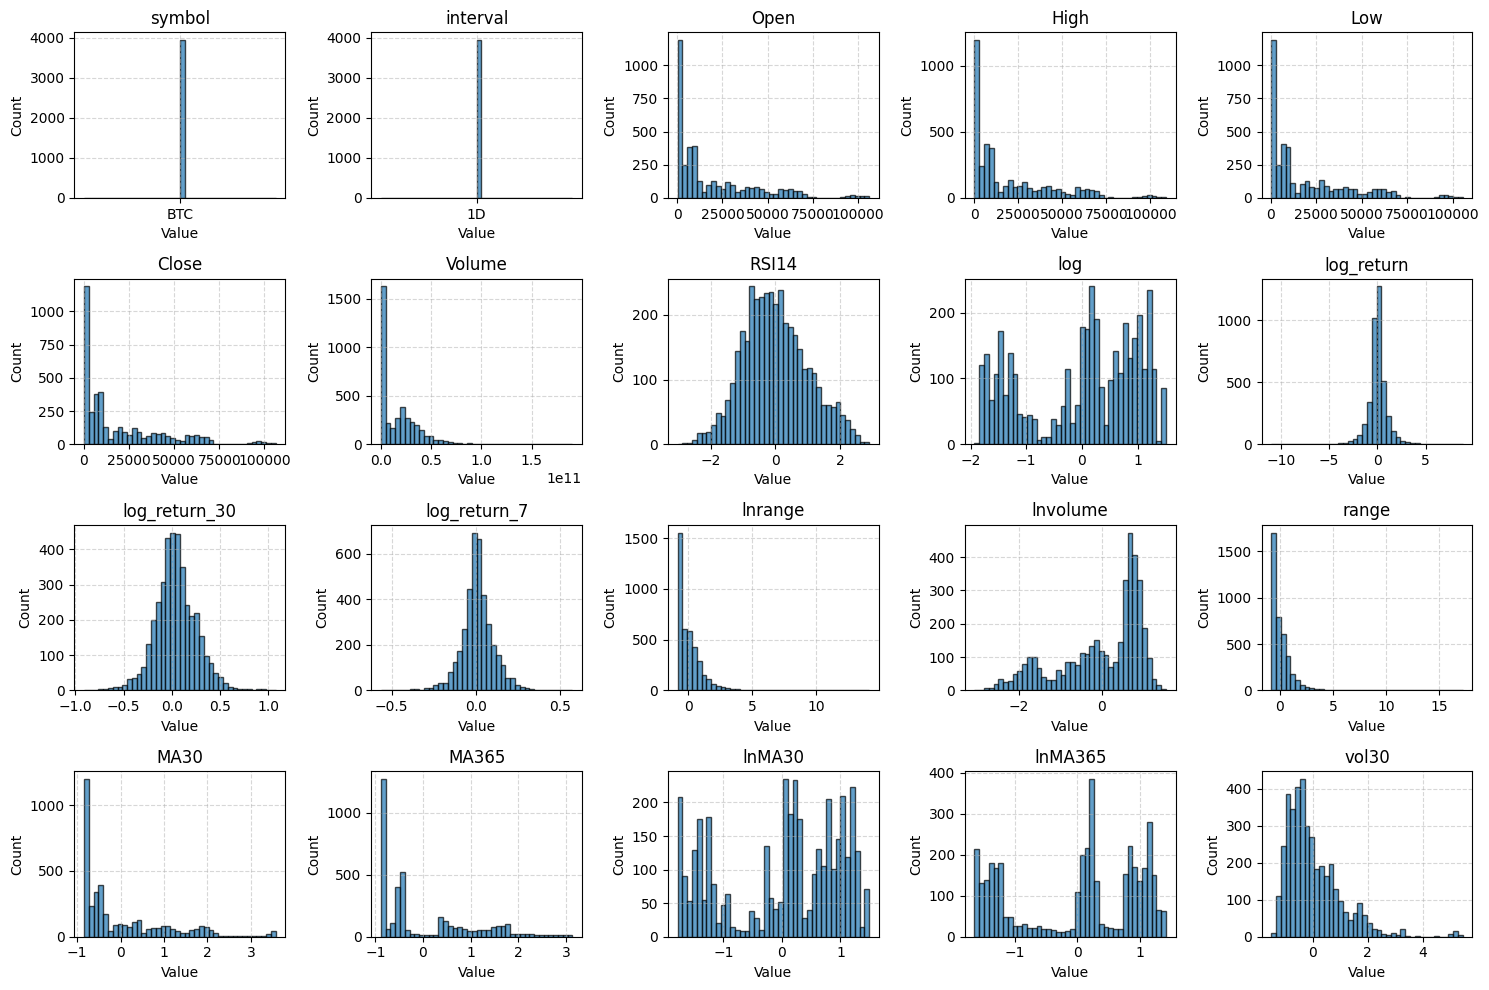

In [3]:
import pandas_ta as ta
from sklearn.preprocessing import StandardScaler

data = data[['Open', 'High', 'Low', 'Close', 'Volume']]

#copy and structure
df = data.copy()

df['RSI14'] = ta.rsi(df['Close'], length=14)

# Basic log transformations
df['log'] = np.log(df['Close'])
df['log_return'] = df['log'].pct_change()
df['log_return_30'] = df['log'].diff(periods=30)
df['log_return_7'] = df['log'].diff(periods=7)
df['lnrange'] = np.log(df['High']/df['Low'])-1
df['lnvolume'] = np.log(df['Volume'])
df['range'] = (df["High"] / df["Low"]) - 1

# Add Moving Averages (and their log transformations)
df['MA30'] = df['Close'].rolling(window=30).mean()
df['MA365'] = df['Close'].rolling(window=365).mean()
df['lnMA30'] = np.log(df['MA30'])
df['lnMA365'] = np.log(df['MA365'])


# Add Rolling Volatility (standard deviation of log returns)
df['vol30'] = df['log_return'].rolling(window=30).std()


# Drop any NaN values that might have been introduced
df.dropna(inplace=True)

scaler = StandardScaler()
features_to_scale = [
    
    'log', 'log_return', 'lnrange', 'lnvolume', 'range', 'lnMA30',
    'lnMA365', 'RSI14', 'vol30', 'MA30', 'MA365'
]

df[features_to_scale] = scaler.fit_transform(df[features_to_scale])


# Add symbol and interval columns
symbol = 'BTC'
interval = '1D'

df.insert(0, 'symbol', symbol.upper())
df.insert(1, 'interval', interval.upper())

plot_feature_distributions(df, feature_cols=df.columns, bins=40)

In [4]:
def split_date_wise(data, 
                    embargo_percent=0.01, 
                    train_start_date=None,
                    train_end_date=None):
    
    #throw error if data in improper form
    if isinstance(data, pd.DataFrame) == False or 'Date' not in data:
        raise ValueError("""Data must be of type pd.DataFrame and contain a 
                         'date' column.""")
       
    #handle no dates given
    if train_start_date == None and train_end_date == None:
        raise ValueError("""At least one of train_start_date and 
                         train_end_date params must be given an argument.""")
 
    #handle end date given but no start
    if train_end_date != None and train_start_date == None:
        train_start_date = data['Date'][0]
 
    #handle start date given but no end
    if train_start_date != None and train_end_date == None:
        raise ValueError('end_date must be given.')
     
    #find start index
    #consider forcing start date to nearest trade day if non-trading day given
    start_index = -1
    for i in range(len(data)):    
        if data['Date'][i] == pd.to_datetime(train_start_date):
            start_index = i 
    
    #raise error if day train_start_date not in data
    if start_index < 0:
        raise ValueError('train_start_date of: ' + train_start_date + 
                         ' not in data.'
                         +' Make sure given date is trading day.')
    
    #find end index
    end_index = -1
    for i in range(len(data)):
        if data['Date'][i] == pd.to_datetime(train_end_date):
            end_index = i
    
    #throw error if day train_start_date not in data
    if end_index < 0:
        raise ValueError(
            'train_end_date of: ' + train_end_date + ' not in data.'
                         +' Make sure given date is trading day.')
    
    #set train, test and embargo set    
    train = data[start_index:end_index+1]
    test = data[round((end_index+1)+(embargo_percent*len(data))):]
    embargo = data[end_index+1:round(end_index+(embargo_percent*len(data))+1)]
    
    #throw error if test set empty
    if len(test) == 0:
        raise ValueError(
            'No data in test set, reduce embargo size or date range.')
    
    #warn if embargo length short
    if len(embargo) < 5:
        import warnings
        warnings.warn("""<5 embargoed data points means data the model was
                      trained on is likely to leak into test set.""")
      
    return train, embargo, test

def split_rand(data, train_percent):

    train = data[np.random.rand(len(data)) < 0.8]
    test = data[~np.random.rand(len(data)) < 0.8]
    
    return train, test

In [5]:
df.reset_index(inplace=True)
train, embargo, test = split_date_wise(df,
                                     embargo_percent=0.005,
                                     train_start_date=None,
                                     train_end_date='2020-12-31')

In [6]:
import hmmlearn.hmm as hmm
from hmmlearn.hmm import GaussianHMM
import numpy as np
import random

# Set random seeds for reproducibility
np.random.seed(4214609)  # for numpy operations
random.seed(4214609)     # for Python's random module


#set features
f_train = train[['Date', 'log_return', 'log_return_30', 'log_return_7']].set_index('Date')
f_test = test[['Date', 'log_return', 'log_return_30', 'log_return_7']].set_index('Date')
hmm = GaussianHMM(n_components=3, 
                  covariance_type="full", n_iter=100000000).fit(f_train)
 
#predict hidden states on test set
hidden_states = hmm.predict(f_test)

## Long-Only


In [12]:
#state 0 mean return and var
s0_mean_ret = hmm.means_[0]
s0_mean_ret = s0_mean_ret[0]
s0_var_ret = np.diag(hmm.covars_[0])
s0_var_ret = s0_var_ret[0]
 
#state 1 mean return and var
s1_mean_ret = hmm.means_[1]
s1_mean_ret = s1_mean_ret[0]
s1_var_ret = np.diag(hmm.covars_[1])
s1_var_ret = s1_var_ret[0]
 
#state 2 mean return and var
s2_mean_ret = hmm.means_[2]
s2_mean_ret = s2_mean_ret[0]
s2_var_ret = np.diag(hmm.covars_[2])
s2_var_ret = s2_var_ret[0]
 
#find favoured state (return wise, no account for var)
if s0_mean_ret > s1_mean_ret and s0_mean_ret > s2_mean_ret:
    fav_state = 0    
if s1_mean_ret > s0_mean_ret and s1_mean_ret > s2_mean_ret:
    fav_state = 1
if s2_mean_ret > s0_mean_ret and s2_mean_ret > s1_mean_ret:
    fav_state = 2
 
#create time series of states
hmm_state_series = test.copy()
hmm_state_series.drop(['Open','High','Low','Close','Volume','log_return',
                       'lnrange','lnvolume','range'],
                      axis=1,inplace=True)
 
hmm_state_series['hidden _state'] = hidden_states
 
hmm_state_series.loc[hmm_state_series['hidden _state'] 
                     == fav_state,'state'] = 'Long'
 
hmm_state_series.loc[hmm_state_series['hidden _state'] 
                     != fav_state,'state'] = 'Flat'
 
hmm_state_series['return'] = hmm_state_series['log'].pct_change()
                                                               
#create df of state certainty
p_of_states = pd.DataFrame(hmm.predict_proba(f_test))
 
#create df of probability curr state is favourable (mean_ret > 0)
fav = p_of_states[fav_state]
p_of_states_fav_unfav = pd.DataFrame(fav)
 
unfav = []
for i in fav:
    j = 1-i
    unfav.append(j)
 
p_of_states_fav_unfav.insert(1,'unfav',unfav)

array([[<Axes: title={'center': '1'}>, <Axes: title={'center': 'unfav'}>]],
      dtype=object)

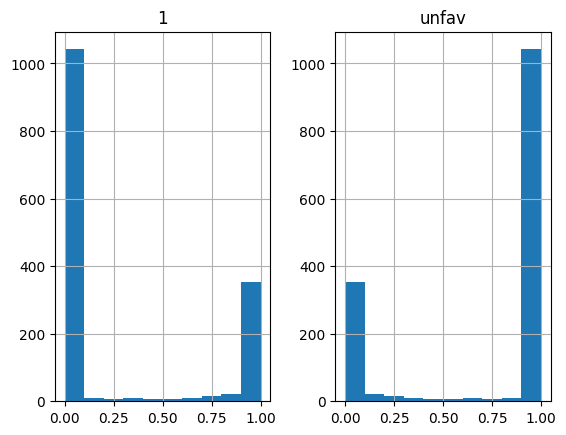

In [13]:
p_of_states_fav_unfav.hist()

## Long Short

In [19]:
import numpy as np
import pandas as pd

# Extract the first dimension's mean (i.e., mean log_return) for each state
s0_mean_ret = hmm.means_[0][0]  
s1_mean_ret = hmm.means_[1][0]
s2_mean_ret = hmm.means_[2][0]

state_means = [s0_mean_ret, s1_mean_ret, s2_mean_ret]
print("State means:", state_means)  # Debug print

# Identify which index (0,1,2) has the highest and lowest returns
max_state = np.argmax(state_means)
min_state = np.argmin(state_means)
print(f"Max state: {max_state}, Min state: {min_state}")  # Debug print

hmm_state_series = test.copy()

# Drop unneeded columns
columns_to_keep = ['log']  
hmm_state_series = hmm_state_series[columns_to_keep]

# Add state information
hmm_state_series['hidden _state'] = hidden_states

# Default everything to "Flat"
hmm_state_series['state'] = 'Flat'

# Assign Long/Short states
hmm_state_series.loc[hmm_state_series['hidden _state'] == max_state, 'state'] = 'Long'
hmm_state_series.loc[hmm_state_series['hidden _state'] == min_state, 'state'] = 'Short'

# Add returns
hmm_state_series['return'] = hmm_state_series['log'].pct_change()

# Get state probabilities with proper index and column names
p_of_states = pd.DataFrame(
    hmm.predict_proba(f_test),
    index=f_test.index,
    columns=[f'state_{i}' for i in range(3)]  # Create column names
)

# Create fav/unfav probabilities
p_of_states_fav_unfav = pd.DataFrame(index=f_test.index)
p_of_states_fav_unfav['fav'] = p_of_states[f'state_{max_state}']  # Use string column name
p_of_states_fav_unfav['unfav'] = 1 - p_of_states_fav_unfav['fav']

# Debug prints
print("\nShape of p_of_states:", p_of_states.shape)
print("Shape of p_of_states_fav_unfav:", p_of_states_fav_unfav.shape)
print("\nFirst few rows of p_of_states_fav_unfav:")
print(p_of_states_fav_unfav.head())

State means: [-0.00890967750865586, 0.14990783718073297, -0.14242843397945348]
Max state: 1, Min state: 2

Shape of p_of_states: (1480, 3)
Shape of p_of_states_fav_unfav: (1480, 2)

First few rows of p_of_states_fav_unfav:
                     fav         unfav
Date                                  
2021-01-21  1.055173e-48  1.000000e+00
2021-01-22  9.989425e-01  1.057520e-03
2021-01-23  9.999997e-01  3.289442e-07
2021-01-24  1.000000e+00  1.952139e-08
2021-01-25  9.999999e-01  6.822279e-08


array([[<Axes: title={'center': 'fav'}>,
        <Axes: title={'center': 'unfav'}>]], dtype=object)

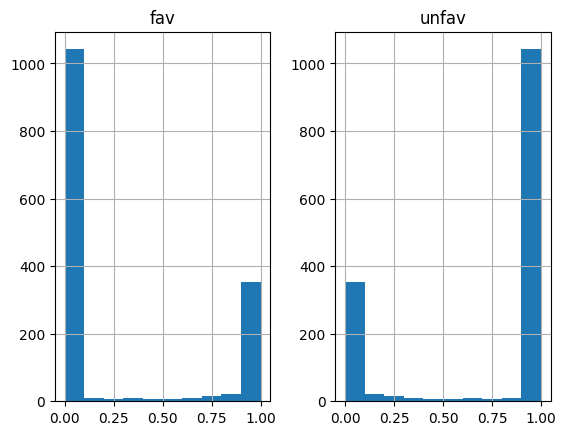

In [21]:
p_of_states_fav_unfav.hist()

## Long Only Trades

In [ ]:
def transact_at_open(test, hmm_state_series, p_of_states_fav_unfav):
    """
    Given the test data (with price info), the HMM state assignments,
    and the probability DataFrame (with a column 'unfav' that gives the probability 
    that the current state is not the favorable one), this function:
      - Merges everything into one DataFrame.
      - Shifts the state signal forward one row (since the state is determined from close values)
      - Computes the daily open-to-open returns.
      - Computes a strategy’s daily and cumulative returns assuming you trade only
        at the open when your signal (Long vs Flat) changes.
    
    Parameters:
      test : pd.DataFrame
          The test dataset that includes at least a Date and Open price column.
      hmm_state_series : pd.DataFrame
          The DataFrame that (at a minimum) contains the columns 
          'hidden _state' (the raw state assigned by the HMM) and
          'state' (a text label such as "Long" or "Flat").
      p_of_states_fav_unfav : pd.DataFrame
          A DataFrame (indexed by Date) that contains at least the column 
          'unfav' giving the probability that the current state is unfavorable.
    
    Returns:
      result : pd.DataFrame
          A copy of the test set with extra columns:
            - 'hidden _state' and 'state' (the original HMM assignments)
            - 'unfav' (the unfavored probability)
            - 'signal' (the state signal shifted forward one row)
            - 'position' (1 when signal == "Long", else 0)
            - 'open_return' (next day’s open-to-open return, computed as Open[i+1] / Open[i] - 1)
            - 'strategy_return' (daily return if in a long position, else 0)
            - 'cum_strategy_return' (cumulative return for the strategy)
            - 'cum_buy_hold_return' (cumulative return from simply trading the asset’s open price)
            - 'trade' (flag marking a change in signal)
    """
    
    # Make a copy of test data to start with
    result = test.copy()
    
    # Ensure p_of_states_fav_unfav has the same index as test
    p_of_states_fav_unfav.index = test.index
    
    # Join in the HMM state information
    result = result.join(hmm_state_series[['hidden _state', 'state']])
    
    # Now join the unfav probability
    result = result.join(p_of_states_fav_unfav['unfav'])
    
    # Verify the join worked
    if result['unfav'].isna().all():
        print("Warning: unfav column is all NaN. Debugging info:")
        print(f"result index: {result.index[:5]}")
        print(f"p_of_states_fav_unfav index: {p_of_states_fav_unfav.index[:5]}")
    
    # Rest of the function remains the same
    result['signal'] = result['state'].shift(1)
    result['position'] = np.where(result['signal'] == 'Long', 1, 0)
    result['next_open'] = result['Open'].shift(-1)
    result['open_return'] = result['next_open'] / result['Open'] - 1
    result['open_return'] = result['open_return'].fillna(0)
    result['strategy_return'] = result['position'] * result['open_return']
    result['trade'] = (result['signal'] != result['signal'].shift(1)).astype(int)
    result['cum_strategy_return'] = (1 + result['strategy_return']).cumprod() - 1
    result['cum_buy_hold_return'] = (1 + result['open_return']).cumprod() - 1
    result.drop(['next_open'], axis=1, inplace=True)
    
    return result

# =============================================================================
# EXAMPLE USAGE:
# (Assuming that you have already defined the following from your earlier script:)
#   - test           : your test set DataFrame (with Date, Open, etc.)
#   - hmm_state_series: the DataFrame holding the HMM-assigned states and the "Long"/"Flat" labels.
#   - p_of_states_fav_unfav: DataFrame with the probabilities (including column 'unfav').
# =============================================================================

# For example, you might call:
compiled_df = transact_at_open(test, hmm_state_series, p_of_states_fav_unfav)
compiled_df

## Long Short Trades    

In [24]:
def transact_at_open(test, hmm_state_series, p_of_states_fav_unfav):
    """
    Now includes short positions when state=='Short'.
    """
    
    # Make a copy of test data
    result = test.copy()
    
    # Ensure alignment of indexes
    p_of_states_fav_unfav.index = test.index
    
    # Merge HMM state info
    result = result.join(hmm_state_series[['hidden _state', 'state']])
    
    # Merge “unfav” probability
    result = result.join(p_of_states_fav_unfav['unfav'])
    
    # Shift the signal by 1 day (so you trade at today's open
    # based on yesterday's close-based regime)
    result['signal'] = result['state'].shift(1)
    
    # Map the signal to a position: +1 for Long, –1 for Short, 0 for Flat
    def map_position(signal):
        if signal == 'Long':
            return 1
        elif signal == 'Short':
            return -1
        else:
            return 0

    result['position'] = result['signal'].apply(map_position)
    
    # Next day's open price for return computation
    result['next_open'] = result['Open'].shift(-1)
    
    # Open-to-open daily return
    result['open_return'] = result['next_open'] / result['Open'] - 1
    result['open_return'] = result['open_return'].fillna(0)
    
    # Strategy’s return if in a position (positive or negative)
    # position * open_return automatically handles shorting
    result['strategy_return'] = result['position'] * result['open_return']
    
    # Mark when you change signals
    result['trade'] = (result['signal'] != result['signal'].shift(1)).astype(int)
    
    # Cumulative return series
    result['cum_strategy_return'] = (1 + result['strategy_return']).cumprod() - 1
    result['cum_buy_hold_return'] = (1 + result['open_return']).cumprod() - 1
    
    result.drop(['next_open'], axis=1, inplace=True)
    
    return result

compiled_df = transact_at_open(test, hmm_state_series, p_of_states_fav_unfav)
compiled_df


,Date,symbol,interval,Open,High,Low,Close,Volume,RSI14,log,...,hidden _state,state,unfav,signal,position,open_return,strategy_return,trade,cum_strategy_return,cum_buy_hold_return
2458,2021-01-21,BTC,1D,35978.0,36318.0,33636.0,35587.0,6.941531e+10,0.243076,0.924375,...,2,Short,1.000000e+00,None,0,-0.010340,-0.000000,1,0.000000,-0.010340
2459,2021-01-22,BTC,1D,35606.0,35606.0,30358.0,30914.0,6.954974e+10,-0.641236,0.848972,...,1,Long,1.057520e-03,Short,-1,-0.134921,0.134921,1,0.134921,-0.143866
2460,2021-01-23,BTC,1D,30802.0,33771.0,29043.0,32958.0,4.357541e+10,-0.269263,0.883267,...,1,Long,3.289442e-07,Long,1,0.067041,0.067041,1,0.211007,-0.086470
2461,2021-01-24,BTC,1D,32867.0,33328.0,31481.0,32068.0,4.281054e+10,-0.417025,0.868603,...,1,Long,1.952139e-08,Long,1,-0.024371,-0.024371,0,0.181494,-0.108733
2462,2021-01-25,BTC,1D,32066.0,32927.0,31089.0,32274.0,5.041055e+10,-0.378162,0.872033,...,1,Long,6.822279e-08,Long,1,0.006144,0.006144,0,0.188753,-0.103258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3933,2025-02-04,BTC,1D,101392.0,101730.0,96026.0,98118.0,7.319669e+10,-0.581879,1.467615,...,0,Flat,9.999633e-01,Flat,0,0.000000,0.000000,0,12.254374,1.818167
3934,2025-02-05,BTC,1D,101392.0,101730.0,96026.0,98118.0,4.884896e+10,-0.581879,1.467615,...,0,Flat,9.999507e-01,Flat,0,-0.034559,-0.000000,0,12.254374,1.720774
3935,2025-02-06,BTC,1D,97888.0,98949.0,96212.0,96583.0,4.446218e+10,-0.772469,1.459169,...,0,Flat,9.997331e-01,Flat,0,-0.013025,-0.000000,0,12.254374,1.685335
3936,2025-02-07,BTC,1D,96613.0,99132.0,95820.0,96635.0,5.707772e+10,-0.763568,1.459457,...,0,Flat,9.996372e-01,Flat,0,-0.000466,-0.000000,0,12.254374,1.684085


<Axes: >

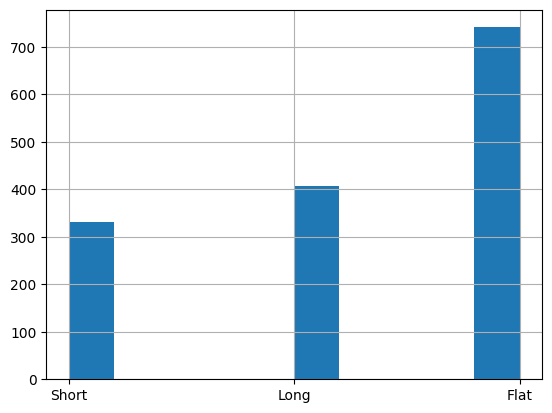

In [25]:
compiled_df['state'].hist()

In [26]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_hmm_results(df):
    """
    Given a DataFrame (such as that returned by transact_at_open()) that includes:
      - Date (as a column)
      - 'hidden _state': the raw state from the HMM (e.g. 0, 1, or 2)
      - 'cum_buy_hold_return': cumulative return from buying and holding the asset
      - 'cum_strategy_return': cumulative return from the HMM-based strategy
      - 'unfav': the probability that the state is unfavored
    this function produces a two-panel interactive Plotly plot.
    """
    
    # Ensure Date is datetime
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    
    # Create figure with secondary y-axis
    fig = make_subplots(rows=2, cols=1, 
                       shared_xaxes=True,
                       vertical_spacing=0.1,
                       row_heights=[0.7, 0.3])

    # Top Panel: Returns
    # Scatter plot for buy & hold returns colored by state
    fig.add_trace(
        go.Scatter(
            x=df['Date'],
            y=df['cum_buy_hold_return'],
            mode='markers',
            name='Buy & Hold',
            marker=dict(
                size=3,
                color=df['hidden _state'],
                colorscale='Viridis',
                showscale=True,
                colorbar=dict(title='Hidden State')
            )
        ),
        row=1, col=1
    )
    
    # Line plot for strategy returns
    fig.add_trace(
        go.Scatter(
            x=df['Date'],
            y=df['cum_strategy_return'],
            mode='lines',
            name='HMM Strategy',
            line=dict(color='red', width=2)
        ),
        row=1, col=1
    )
    
    # Bottom Panel: Unfavored Probability
    fig.add_trace(
        go.Scatter(
            x=df['Date'],
            y=df['unfav'],
            mode='lines',
            name='Unfavored Probability',
            line=dict(color='black', width=2)
        ),
        row=2, col=1
    )
    
    # Update layout
    fig.update_layout(
        title='HMM-Regime Based Strategy Analysis',
        template='plotly_white',
        height=800,
        showlegend=True,
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        )
    )
    
    # Update y-axes labels
    fig.update_yaxes(title_text="Cumulative Return", row=1, col=1)
    fig.update_yaxes(title_text="Unfavored Probability", row=2, col=1)
    
    # Update x-axis label
    fig.update_xaxes(title_text="Date", row=2, col=1)
    
    # Show the plot
    fig.show()

# Example usage:
plot_hmm_results(compiled_df)